Computing the integral of a function using a fitting method

In [1]:
# Modules
import numpy as np
from scipy.integrate import quad # To get the real value of the integral
import matplotlib.pyplot as plt

In [2]:
# Computes the integral of a function f using the trapezoid method with severals steps
def trap(f, a, b, max_N):

    N_values = np.arange(1, max_N + 1)
    integrals_list = []
    h_list = []
    
    for N in N_values:
        x = np.linspace(a, b, N + 1)
        y = f(x)
        h = (b - a) / N
        h_list.append(h)
        integrals_list.append(np.trapezoid(y, x))
    
    return (N_values, np.array(h_list), np.array(integrals_list))

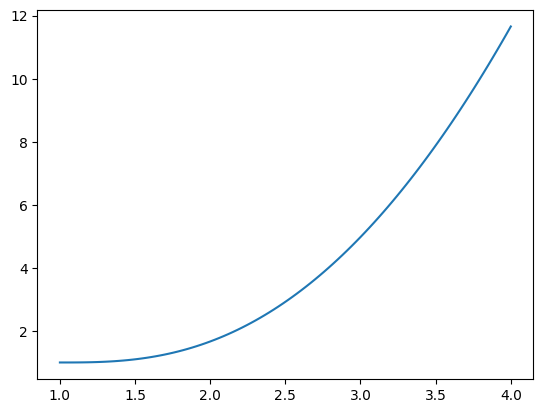

In [3]:
f = lambda x: x * np.log(x) ** 3 + 1 # f = x * log(x) ** 3 + 1
a, b, max_N = (1, 4, 100) # small number of subdivisions

# Fast plot of f
x = np.linspace(a, b, 100)
plt.plot(x, f(x))
plt.show()

In [4]:
# Computing the integrals
Ns, hs, Is = trap(f, a, b, max_N)
Ns, hs, Is

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100]),
 array([3.        , 1.5       , 1.        , 0.75      , 0.6       ,
        0.5       , 0.42857143, 0.375     , 0.33333333, 0.3       ,
        0.27272727, 0.25      , 0.23076923, 0.21428571, 0.2       ,
        0.1875    , 0.17647059, 0.16666667, 0.15789474, 0.15      ,
        0.14285714, 0.13636364, 0.13043478, 0.125     , 0.12      ,
        0.11538462, 0.11111111, 0.10714286, 0.10344828, 0.1       ,
        0.09677419, 0.0937

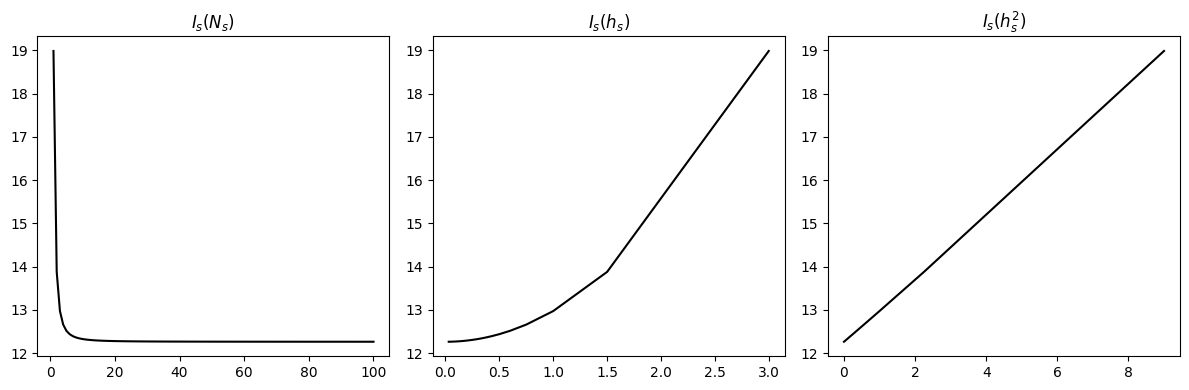

In [5]:
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

# Plot 1: Is(Ns)
axes[0].plot(Ns, Is, 'k-')
axes[0].set_title('$I_s (N_s)$')

# Plot 2: Is(hs)
axes[1].plot(hs, Is, 'k-')
axes[1].set_title('$I_s (h_s)$')

# Plot 3: Is(hs**2)
axes[2].plot(hs ** 2, Is, 'k-')
axes[2].set_title('$I_s (h_s^2)$')

plt.tight_layout()
plt.show()

Let's fit $I(h ^ 2)$ using a 4th degree polynomial:

$$
    I(x) = a x ^ 4 + b x ^ 3 + c x ^2 + d x + e; \qquad x = h ^ 2;
$$

In [6]:
# Bootstrap method
def bootstrap_fitting(x, y, n_boot = 1_000):

    idx = np.random.randint(0, len(x), (n_boot, len(x))) # Generate all bootstrap indices at once
    boot_params = np.array([np.polyfit(x[i], y[i], 4) for i in idx]) # Vectorized bootstrap sampling
    
    coeff_mean = boot_params.mean(axis = 0)
    coeff_err = 2 * boot_params.std(axis = 0)
    
    labels = ['a', 'b', 'c', 'd', 'e']
    for label, mean_val, err_val in zip(labels, coeff_mean, coeff_err):
        print(f"Bootstrap method: {label} = {mean_val} ± {err_val}")
    
    return (coeff_mean[-1], coeff_err[-1]) # Returns the integral estimation and its error

# Jackknife method
def jackknife_fitting(x, y):

    jack_params = np.empty((len(x), 5))
    
    for i in range(len(x)):
        x_jack = np.delete(x, i)
        y_jack = np.delete(y, i)
        jack_params[i] = np.polyfit(x_jack, y_jack, 4)
    
    coeff_mean = jack_params.mean(axis = 0)
    coeff_err = 2 * np.sqrt((len(x) - 1) / len(x) * ((jack_params - coeff_mean) ** 2).sum(axis = 0))
    
    labels = ['a', 'b', 'c', 'd', 'e']
    for label, mean_val, err_val in zip(labels, coeff_mean, coeff_err):
        print(f"Jackknife method: {label} = {mean_val} ± {err_val}")
    
    return (coeff_mean[-1], coeff_err[-1]) # Returns the integral estimation and its error

# Covariance method
def covariance_fitting(x, y):

    params, cov = np.polyfit(x, y, 4, cov = True) # Set cov = True
    coeff_err = 2 * np.sqrt(np.diag(cov))
    
    labels = ['a', 'b', 'c', 'd', 'e']
    for _, (label, param, err) in enumerate(zip(labels, params, coeff_err)):
        print(f"Covariance method: {label} = {param} ± {err}")
    
    return (params[-1], coeff_err[-1]) # Returns the integral estimation and its error

In [7]:
n = max_N // 100 * 30 # Just take 30 % of the data near h = 0
x, y = hs[- n:] ** 2, Is[- n:]

# Fitting results
e_b, err_e_b = bootstrap_fitting(x, y)

print('*' * 60)

e_j, err_e_j = jackknife_fitting(x, y)

print('*' * 60)

e, err_e = covariance_fitting(x, y)

Bootstrap method: a = -0.07556031080078057 ± 0.3619888062885188
Bootstrap method: b = -0.0005728599990047049 ± 0.001907437145317069
Bootstrap method: c = 0.00831213803083034 ± 3.727317172497529e-06
Bootstrap method: d = 0.7024694493094874 ± 3.1976091619138214e-09
Bootstrap method: e = 12.262365392656314 ± 1.0189743346393654e-12
************************************************************
Jackknife method: a = -0.06267557254758171 ± 1.7445878606560037
Jackknife method: b = -0.0006311079058122647 ± 0.008875093974987081
Jackknife method: c = 0.008312235383253024 ± 1.67075269307139e-05
Jackknife method: d = 0.7024694492385367 ± 1.378090367807103e-08
Jackknife method: e = 12.262365392656289 ± 4.200475863898871e-12
************************************************************
Covariance method: a = -0.2985331948048201 ± 0.22401564096589086
Covariance method: b = 0.000561939763649585 ± 0.001196608014091515
Covariance method: c = 0.008309997013790302 ± 2.360946062837721e-06
Covariance method: d

In [8]:
# Real_value using quad()
real_value, _ = quad(f, a, b)
real_value

12.262365392656502

In [9]:
print(f"Bootstrap: I - e_b = {abs(real_value - e_b)}")
print(f"Jackknife: I - e_j = {abs(real_value - e_j)}")
print(f"Covariance: I - e = {abs(real_value - e)}")
print(f"Raw estimation: I - I_s(N = {max_N}) = {abs(real_value - Is[-1])}")
print("\n")

k = 1
print("Bootstap OK" if abs(real_value - e_b) <= k * err_e_b else "Bootstap not OK")
print("Jackknife OK" if abs(real_value - e_j) <= k * err_e_j else "Jackknife not OK")
print("Covariance OK" if abs(real_value - e) <= k * err_e else "Covariance not OK") # The covariance method slightly underestimates the error in this scenario

Bootstrap: I - e_b = 1.8829382497642655e-13
Jackknife: I - e_j = 2.1316282072803006e-13
Covariance: I - e = 7.833733661755105e-13
Raw estimation: I - I_s(N = 100) = 0.0006322292365084081


Bootstap OK
Jackknife OK
Covariance not OK
